In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Dataset

# Load dataset
url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"
df = pd.read_csv(url)

# Show basic information
print("Dataset Shape:", df.shape)

# Display first 5 rows
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# Check class distribution

# Count normal vs fraud transactions
class_counts = df["Class"].value_counts()

print(class_counts)

Class
0    284315
1       492
Name: count, dtype: int64


In [6]:
# Feature scaling

# Separate features and labels
X = df.drop("Class", axis=1)
y = df["Class"]

# Scale features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (optional but cleaner)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled feature shape:", X_scaled.shape)
X_scaled.head()

Scaled feature shape: (284807, 30)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.996583,-0.694242,-0.044075,1.672773,0.973366,-0.245117,0.347068,0.193679,0.082637,0.331128,...,0.326118,-0.024923,0.382854,-0.176911,0.110507,0.246585,-0.392170,0.330892,-0.063781,0.244964
1,-1.996583,0.608496,0.161176,0.109797,0.316523,0.043483,-0.061820,-0.063700,0.071253,-0.232494,...,-0.089611,-0.307377,-0.880077,0.162201,-0.561131,0.320694,0.261069,-0.022256,0.044608,-0.342475
2,-1.996562,-0.693500,-0.811578,1.169468,0.268231,-0.364572,1.351454,0.639776,0.207373,-1.378675,...,0.680975,0.337632,1.063358,1.456320,-1.138092,-0.628537,-0.288447,-0.137137,-0.181021,1.160686
3,-1.996562,-0.493325,-0.112169,1.182516,-0.609727,-0.007469,0.936150,0.192071,0.316018,-1.262503,...,-0.269855,-0.147443,0.007267,-0.304777,-1.941027,1.241904,-0.460217,0.155396,0.186189,0.140534
4,-1.996541,-0.591330,0.531541,1.021412,0.284655,-0.295015,0.071999,0.479302,-0.226510,0.744326,...,0.529939,-0.012839,1.100011,-0.220123,0.233250,-0.395202,1.041611,0.543620,0.651816,-0.073403


In [7]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (227845, 30)
Test shape : (56962, 30)


In [8]:
# Keep only normal transactions for VAE training
X_train_normal = X_train[y_train == 0]

print("Normal training samples shape:", X_train_normal.shape)

Normal training samples shape: (227451, 30)


In [20]:
# VARIATIONAL AUTOENCODER #

# Define ENCODER
# Input dimension
input_dim = X_train_normal.shape[1]

# Latent space dimension
latent_dim = 2

In [21]:
# Reparameterization function
def sampling(args):

    z_mean, z_log_var = args

    epsilon = tf.random.normal(
        shape=(tf.shape(z_mean)[0], latent_dim)
    )

    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [22]:
# Build ENCODER
# Encoder input
encoder_inputs = layers.Input(shape=(input_dim,))

# Encoder layers
x = layers.Dense(16, activation="relu")(encoder_inputs)
x = layers.Dense(8, activation="relu")(x)

# Mean and log variance
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

# Sample latent vector
z = layers.Lambda(
    sampling,
    output_shape=(latent_dim,)
)([z_mean, z_log_var])

# Encoder model
encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 30)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_9 (Dense)               │ (None, 16)                │             496 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_10 (Dense)              │ (None, 8)                 │             136 │ dense_9[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean (Dense)                │ (None, 2)                 │              18 │ dense_10[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var (Dense)             │ (None, 2)                 │              18 │ dense_10[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lambda_2 (Lambda)             │ (None, 2)                 │               0 │ z_mean[0][0],              │
│                               │                           │                 │ z_log_var[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 668 (2.61 KB)

 Trainable params: 668 (2.61 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Build DECODER #
# Decoder input
latent_inputs = layers.Input(shape=(latent_dim,))

# Decoder layers
x = layers.Dense(8, activation="relu")(latent_inputs)
x = layers.Dense(16, activation="relu")(x)

# Output layer
decoder_outputs = layers.Dense(
    input_dim,
    activation="linear"
)(x)

# Decoder model
decoder = Model(
    latent_inputs,
    decoder_outputs,
    name="decoder"
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 2)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 8)                   │              24 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 30)                  │             510 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 678 (2.65 KB)

 Trainable params: 678 (2.65 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Custom VAE class
class VAE(Model):

    def __init__(self, encoder, decoder, **kwargs):

        super(VAE, self).__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

    # Forward pass
    def call(self, inputs):

        z_mean, z_log_var, z = self.encoder(inputs)

        reconstruction = self.decoder(z)

        return reconstruction

    # Custom training step
    def train_step(self, data):

        # Unpack input and target
        x, y = data

        with tf.GradientTape() as tape:

            # Encode
            z_mean, z_log_var, z = self.encoder(x)

            # Decode
            reconstruction = self.decoder(z)

            # Reconstruction loss
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.square(x - reconstruction),
                    axis=1
                )
            )

            # KL divergence loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var
                    - tf.square(z_mean)
                    - tf.exp(z_log_var),
                    axis=1
                )
            )

            # Total loss
            total_loss = reconstruction_loss + kl_loss

        # Compute gradients
        grads = tape.gradient(
            total_loss,
            self.trainable_weights
        )

        # Apply gradients
        self.optimizer.apply_gradients(
            zip(grads, self.trainable_weights)
        )

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

In [34]:
# Create/Compile VAE #
# Instantiate VAE
vae = VAE(encoder, decoder)

# Compile with dummy loss
vae.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.MeanSquaredError()
)

print("VAE compiled successfully.")

VAE compiled successfully.


In [35]:
# Convert training data to NumPy
X_train_normal_np = X_train_normal.values.astype("float32")

# Train VAE
history = vae.fit(
    X_train_normal_np,
    X_train_normal_np,
    epochs=30,
    batch_size=256,
    shuffle=True
)

Epoch 1/30
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - kl_loss: 1.5190 - loss: 25.3993 - reconstruction_loss: 23.8802
Epoch 2/30
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - kl_loss: 1.7408 - loss: 24.4402 - reconstruction_loss: 22.6993
Epoch 3/30
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - kl_loss: 1.8471 - loss: 22.3054 - reconstruction_loss: 20.4583
Epoch 4/30
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - kl_loss: 2.2577 - loss: 33.3105 - reconstruction_loss: 31.0528
Epoch 5/30
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - kl_loss: 1.7968 - loss: 21.8774 - reconstruction_loss: 20.0806
Epoch 6/30
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - kl_loss: 1.6913 - loss: 21.2697 - reconstruction_loss: 19.5784
Epoch 7/30
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - kl_loss: 1.7500 - loss: 25.4853 - reconstruction_loss: 23.7354
Epoch 8/30
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - kl_loss: 1.7283 - loss: 21.5497 - reconstruction_loss: 19.8214
Epoch 9/30
889/889 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - kl_loss: 2

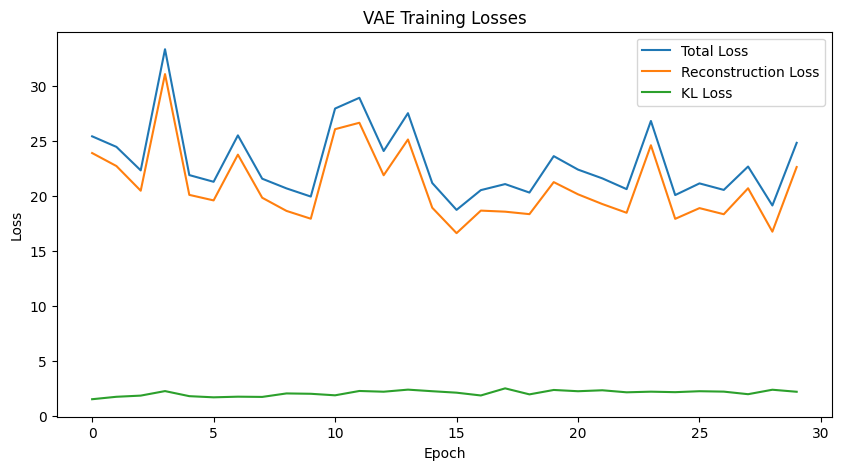

In [36]:
# Training loss plot

plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Total Loss")
plt.plot(history.history["reconstruction_loss"], label="Reconstruction Loss")
plt.plot(history.history["kl_loss"], label="KL Loss")

plt.title("VAE Training Losses")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [37]:
# Prepare test data
# Convert test data to NumPy
X_test_np = X_test.values.astype("float32")

# True labels
y_test_np = y_test.values

In [38]:
# Reconstruct test samples
X_test_pred = vae.predict(X_test_np)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [39]:
# Reconstruction error (MSE per sample)
reconstruction_error = np.mean(
    np.square(X_test_np - X_test_pred),
    axis=1
)

print("Reconstruction errors computed.")

Reconstruction errors computed.


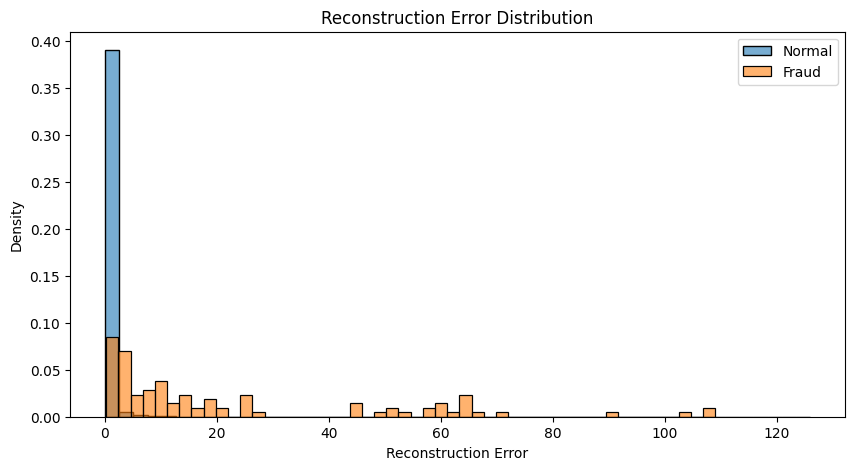

In [40]:
# Plot reconstruction error distributions
plt.figure(figsize=(10,5))

sns.histplot(
    reconstruction_error[y_test_np == 0],
    bins=50,
    label="Normal",
    stat="density",
    alpha=0.6
)

sns.histplot(
    reconstruction_error[y_test_np == 1],
    bins=50,
    label="Fraud",
    stat="density",
    alpha=0.6
)

plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")

plt.legend()

plt.show()

In [41]:
# ROC-AUC Score
roc_auc = roc_auc_score(
    y_test_np,
    reconstruction_error
)

print("VAE ROC-AUC Score:", roc_auc)

VAE ROC-AUC Score: 0.9431357165826376


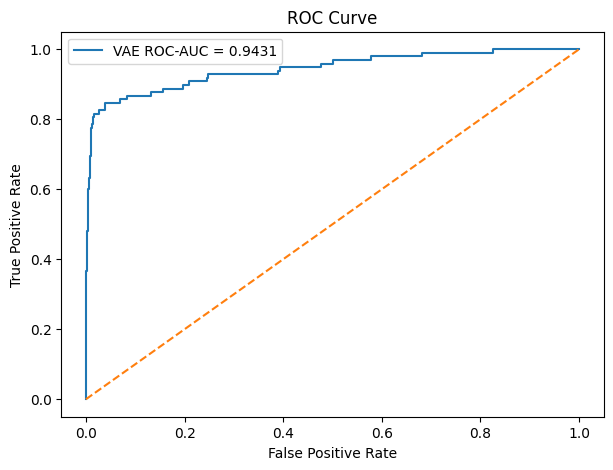

In [42]:
# Compute ROC curve
fpr, tpr, _ = roc_curve(
    y_test_np,
    reconstruction_error
)

# Plot ROC curve
plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"VAE ROC-AUC = {roc_auc:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [43]:
# Precision-Recall values
precision, recall, _ = precision_recall_curve(
    y_test_np,
    reconstruction_error
)

# PR-AUC
pr_auc = auc(recall, precision)

print("VAE PR-AUC:", pr_auc)

VAE PR-AUC: 0.28234977021767227


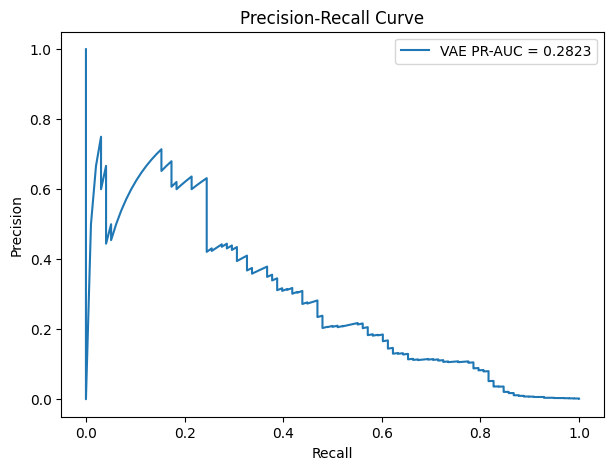

In [44]:
# Plot Precision-Recall curve
plt.figure(figsize=(7,5))

plt.plot(
    recall,
    precision,
    label=f"VAE PR-AUC = {pr_auc:.4f}"
)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()

plt.show()

### Isolation Forest

In [45]:
# train isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.0017,  # approximate fraud ratio
    random_state=42
)

# Train on normal samples only
iso_forest.fit(X_train_normal)

,n_estimators,100
,max_samples,'auto'
,contamination,0.0017
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [46]:
# Anomaly scores
iso_scores = -iso_forest.decision_function(X_test)

# ROC-AUC
iso_roc_auc = roc_auc_score(
    y_test_np,
    iso_scores
)

print("Isolation Forest ROC-AUC:", iso_roc_auc)

Isolation Forest ROC-AUC: 0.9534027841581201


In [47]:
# Precision-Recall
iso_precision, iso_recall, _ = precision_recall_curve(
    y_test_np,
    iso_scores
)

# PR-AUC
iso_pr_auc = auc(iso_recall, iso_precision)

print("Isolation Forest PR-AUC:", iso_pr_auc)

Isolation Forest PR-AUC: 0.16802320193254522


### One-class SVM

In [48]:
# One-Class SVM
ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.0017
)

# Use subset for faster training
X_train_subset = X_train_normal.sample(
    n=20000,
    random_state=42
)

# Train
ocsvm.fit(X_train_subset)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,nu,0.0017
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [49]:
# Anomaly scores
svm_scores = -ocsvm.decision_function(X_test)

# ROC-AUC
svm_roc_auc = roc_auc_score(
    y_test_np,
    svm_scores
)

print("One-Class SVM ROC-AUC:", svm_roc_auc)

# Precision-Recall
svm_precision, svm_recall, _ = precision_recall_curve(
    y_test_np,
    svm_scores
)

# PR-AUC
svm_pr_auc = auc(
    svm_recall,
    svm_precision
)

print("One-Class SVM PR-AUC:", svm_pr_auc)

One-Class SVM ROC-AUC: 0.9568978759202049
One-Class SVM PR-AUC: 0.24444414762992608


In [50]:
# Comparison table
results = pd.DataFrame({
    "Method": [
        "VAE",
        "Isolation Forest",
        "One-Class SVM"
    ],
    "ROC-AUC": [
        roc_auc,
        iso_roc_auc,
        svm_roc_auc
    ],
    "PR-AUC": [
        pr_auc,
        iso_pr_auc,
        svm_pr_auc
    ]
})

results

,Method,ROC-AUC,PR-AUC
0,VAE,0.943136,0.282350
1,Isolation Forest,0.953403,0.168023
2,One-Class SVM,0.956898,0.244444


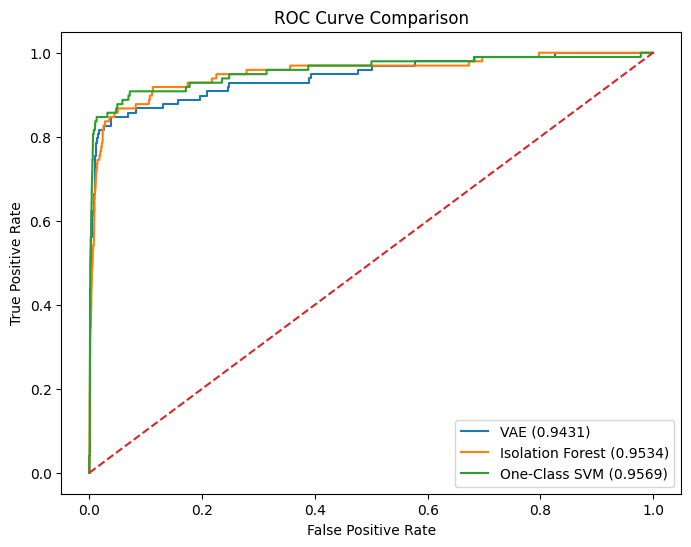

In [51]:
# Combined ROC curves
# Isolation Forest ROC
iso_fpr, iso_tpr, _ = roc_curve(
    y_test_np,
    iso_scores
)

# One-Class SVM ROC
svm_fpr, svm_tpr, _ = roc_curve(
    y_test_np,
    svm_scores
)

# Plot ROC curves
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"VAE ({roc_auc:.4f})"
)

plt.plot(
    iso_fpr,
    iso_tpr,
    label=f"Isolation Forest ({iso_roc_auc:.4f})"
)

plt.plot(
    svm_fpr,
    svm_tpr,
    label=f"One-Class SVM ({svm_roc_auc:.4f})"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

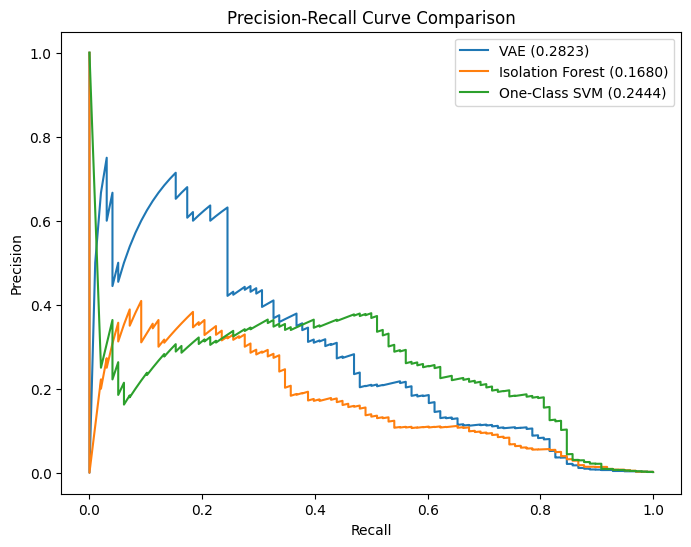

In [52]:
# Combined Precision-Recall curves
# Plot PR curves
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label=f"VAE ({pr_auc:.4f})"
)

plt.plot(
    iso_recall,
    iso_precision,
    label=f"Isolation Forest ({iso_pr_auc:.4f})"
)

plt.plot(
    svm_recall,
    svm_precision,
    label=f"One-Class SVM ({svm_pr_auc:.4f})"
)

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()

plt.show()